In [1]:
1+1

2

In [2]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from scipy.stats import pearsonr


In [3]:
iyr=2000;fyr=2015
domain='GRf_Fed'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)
var='pr';units='mm/month'
nx=ny=10

38.35 39.3 71.85 72.8


In [4]:
sourceData='/bettik/PROJECTS/pr-regional-climate/santolam/'
plotsDir='/bettik/PROJECTS/pr-regional-climate/fainx/figures/'

In [5]:
#model1 - grid
#sourceDataGrid='/home/amoryc/'
#fileName_grF='NST.2000.01.01.00.GRp.nc'
#ds1_grid= xr.open_dataset(sourceDataGrid+fileName_grF)

#field1_SH=ds1_grid['SH'][ny:-ny,nx:-nx]
 #ds1_ICE=ds1_grid['ICE']#[ny:-ny,nx:-nx]
#field1_SH.shape

In [6]:
#model 1
model1='MAR';res1=str('7kmx7km')
ds_RF_gp=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRp/spin2/work/monthly/'
                          +'RF_mon_MARv3.14_ER5_spin2_GRp_1980-2024.nc')['RF']
ds_SF_gp=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRp/spin2/work/monthly/'
                          +'SF_mon_MARv3.14_ER5_spin2_GRp_1980-2024.nc')['SF']
ds_TF_gp=ds_RF_gp+ds_SF_gp
field_gp=ds_TF_gp.rename({'TIME': 'time'})
field_gp=field_gp[:,ny:-ny,nx:-nx].sel(time=slice(str(iyr),str(fyr)))
field_gp.shape

(192, 62, 96)

In [7]:
ds_gr_7km= xr.open_dataset('/home/amoryc/NST.2000.01.01.00.GRp.nc')
field_gp_SH=ds_gr_7km.SH[ny:-ny,nx:-nx]
field_gp_SH.shape

LONS_7km=ds_gr_7km.LON[ny:-ny,nx:-nx].values
LATS_7km=ds_gr_7km.LAT[ny:-ny,nx:-nx].values

In [8]:
####
model3='aphro'
res3=str('0.25°x0.25°')

fileName3='APHRO_mon_MA_025deg_V1101_EXR1.1951-2015.nc'
ds3 = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/aphro/monthly/'
                      +fileName3,decode_times=False)['precip']
start_date = pd.Timestamp('1951-01-01')
# Create new time index
nmonths = ds3.time.size
time_new = pd.date_range(start=start_date, periods=nmonths, freq='MS')  # 'MS' = Month Start
# Replace time in dataset
ds3['time'] = time_new

ds3=ds3.rename({'latitude':'lat','longitude':'lon'})
field3_mm_day=dom.field_dom(ds3,domain)
field3_mm_day=field3_mm_day.sel(time=slice(str(iyr),str(fyr)))

# Convert mm/day to mm/month
days_in_month = field3_mm_day['time'].dt.days_in_month
field3= field3_mm_day * days_in_month

field3.shape

(192, 4, 4)

In [9]:
##model 3
ds3_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_aphro.nc')['elevation']
field3_SH=dom.field_dom(ds3_SH,domain)
field3_SH.shape

(4, 4)

In [10]:
###model 4
model4='gpcp'
res4=str('1.0°x1.0°')

fileName4='precip_mon.gpcp_v2020_1891_2019_10.nc'
ds4= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/'
                     +model4+'/'+fileName4)['precip']
print(ds4.attrs) 
ds4=dom.reversing_lat(ds4)
#units in mm/month -> mm/day
field4=dom.field_dom(ds4,domain)

#month_length = field40.time.dt.days_in_month
#
#field4=field40/month_length
field4=field4.sel(time=slice(str(iyr),str(fyr)))
field4.shape

{'long_name': 'gpcc full data monthly product version 2020, precipitation per grid', 'units': 'mm/month', 'code': np.int32(20), 'institution': 'DWD'}


(192, 1, 1)

In [11]:
ds4_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_gpcp.nc')['elevation']
field4_SH=dom.field_dom(ds4_SH,domain)
field4_SH.shape

(1, 1)

In [12]:
##model5
model5='cru'
res5=str('0.5°x0.5°')

fileName5='cru_ts4.05.1901.2020.pre.dat.nc'
ds5 = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/'+model5+'/'+fileName5)['pre']
print(ds5.attrs)

#units in mm/month -> mm/day
field5=dom.field_dom(ds5,domain)
#month_length5 = field50.time.dt.days_in_month
#
#field5=field50/month_length5
field5=field5.sel(time=slice(str(iyr),str(fyr)))
field5.shape

{'long_name': 'precipitation', 'units': 'mm/month', 'correlation_decay_distance': np.float32(450.0)}


(192, 2, 2)

In [13]:
##
ds5_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_cru_hma_grid.nc')['elevation']
field5_SH=dom.field_dom(ds5_SH,domain)
field5_SH.shape

(2, 2)

In [14]:
model6='chirps'
res6='0.05°x0.05°'
fileName6='chirps-v2.0.monthly.nc'
ds6 = xr.open_dataset(sourceData+model6+'/'+fileName6)['precip']
ds6=ds6.rename({'latitude':'lat','longitude':'lon'})
field6=dom.field_dom(ds6,domain)


print(field6.shape)

(531, 19, 19)


In [15]:
##
ds6_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_chirps_hma_grid.nc')['elevation']
field6_SH=dom.field_dom(ds6_SH,domain)
field6_SH.shape

(19, 19)

In [16]:
model7='HARv2'
res7='10kmx10km'
#variable='prcp'
fileName7='HARv2_mon_d10km_d_2d_prcp_1980-2023.nc'
ds7_raw0= xr.open_dataset(sourceData+'/'+model7+'/'+fileName7)['prcp']
ds7_raw=ds7_raw0*24 #mm/h
# Calculate days in each month
days_in_month7= ds7_raw['time'].dt.days_in_month
# Convert to mm/month
ds7= ds7_raw* days_in_month7
def xy_sel_dom(ds,domain):
    latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
        print(dim)
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

# Apply mask (non-NaN where the condition is True)
#hgt_subset = hgt.where(mask, drop=True)
field7=xy_sel_dom(ds7.sel(time=slice(str(iyr),str(fyr))),domain)

time
lon
lat
west_east
south_north


In [17]:
domain

'GRf_Fed'

In [18]:
fileName7_grF='HARv2_d10km_static_hgt.nc'
##fileName_grM='NST.2000.01.01.00.GRa_Mera.nc_ICEmask'
ds7_grM= xr.open_dataset(sourceData+'/'+model7+'/'+fileName7_grF)
ds7SH=ds7_grM['hgt'][0,:,:]
#dsSH
field7_SH=xy_sel_dom(ds7SH,domain)


time
west_east
south_north
lon
lat


In [19]:
dsList=[field_gp,
        field3,field4,field5,
        field6,field7]
modelList=[model1,
           model3,model4,model5,
           model6,model7]
resList=['7kmx7km',
         res3,res4,res5,
         res6,res7]
nameList=list(zip(modelList,resList))

In [20]:
print(nameList)

[('MAR', '7kmx7km'), ('aphro', '0.25°x0.25°'), ('gpcp', '1.0°x1.0°'), ('cru', '0.5°x0.5°'), ('chirps', '0.05°x0.05°'), ('HARv2', '10kmx10km')]


In [21]:
#valsList_DJF = [climb.seasonal_selection(elem, 'DJF', iyr, fyr)[0] for elem in dsList]
#valsList_MAM= [climb.seasonal_selection(elem, 'MAM', iyr, fyr)[0] for elem in dsList]
#valsList_JJA= [climb.seasonal_selection(elem, 'JJA', iyr, fyr)[0] for elem in dsList]
#valsList_SON = [climb.seasonal_selection(elem, 'SON', iyr, fyr)[0] for elem in dsList]


In [22]:
len(dsList)

6

In [23]:
elevList=[field_gp_SH,field3_SH,field4_SH,field5_SH,field6_SH,field7_SH]
print(len(elevList))

6


In [24]:
colors=['b','orange', 'pink', 'red', 'green', 'black']

In [25]:
level_bounds = [(0, 2500), (2500, 4500), (4500, 5500), (5500, 7500)]
level_bounds[0][1]

2500

In [26]:
level_bounds = [(0, 2500), (2500, 4500), (4500, 5500), (5500, 7500)]
maskList = []

for elev in elevList:
    masks_per_field = []
    for lev_min, lev_max in level_bounds:
        mask = (elev >= lev_min) & (elev < lev_max)
        masks_per_field.append(mask)
    maskList.append(masks_per_field)

# Check: number of datasets and levels per dataset
print(len(maskList))           # Should be 6 (number of datasets)
print(len(maskList[0]))

6
4


In [27]:
#maskList_field1 = []
#for lev_min, lev_max in level_bounds:
#    mask = (field1_SH >= lev_min) & (field1_SH < lev_max)
#    maskList_field1.append(mask)

maskList_field3 = []
for lev_min, lev_max in level_bounds:
    mask = (field3_SH >= lev_min) & (field3_SH < lev_max)
    maskList_field3.append(mask)

maskList_field4 = []
for lev_min, lev_max in level_bounds:
    mask = (field4_SH >= lev_min) & (field4_SH < lev_max)
    maskList_field4.append(mask)

maskList_field5 = []
for lev_min, lev_max in level_bounds:
    mask = (field5_SH >= lev_min) & (field5_SH < lev_max)
    maskList_field5.append(mask)

maskList_field6 = []
for lev_min, lev_max in level_bounds:
    mask = (field6_SH >= lev_min) & (field6_SH < lev_max)
    maskList_field6.append(mask)
    
maskList_field7 = []
for lev_min, lev_max in level_bounds:
    mask = (field7_SH >= lev_min) & (field7_SH < lev_max)
    maskList_field7.append(mask)

In [28]:
maskList_field_gp = []
for lev_min, lev_max in level_bounds:
    mask = (field_gp_SH >= lev_min) & (field_gp_SH < lev_max)
    maskList_field_gp.append(mask)

In [29]:
#field1_season = field1.groupby('time.month').mean('time', skipna=True)
field_gp_season = field_gp.groupby('time.month').mean('time', skipna=True)

field3_season = field3.groupby('time.month').mean('time', skipna=True)
field4_season = field4.groupby('time.month').mean('time', skipna=True)
field5_season = field5.groupby('time.month').mean('time', skipna=True)
field6_season = field6.groupby('time.month').mean('time', skipna=True)
field7_season = field7.groupby('time.month').mean('time', skipna=True)

def compute_mean_for_masks(field_season, mask_list, dims):
    mean_vals = []
    for mask in mask_list:
        masked = field_season.where(mask.values)
        for dim in dims:
            masked = masked.mean(dim)
        mean_vals.append(masked)
    return mean_vals


#ac_mean_vals_field1 = compute_mean_for_masks(field1_season, maskList_field1,  ['X', 'Y'])
ac_mean_vals_field_gp = compute_mean_for_masks(field_gp_season, maskList_field_gp,  ['X', 'Y'])

ac_mean_vals_field3 = compute_mean_for_masks(field3_season, maskList_field3, ['lon', 'lat'])
ac_mean_vals_field4= compute_mean_for_masks(field4_season, maskList_field4,  ['lon', 'lat'])
ac_mean_vals_field5= compute_mean_for_masks(field5_season, maskList_field5,  ['lon', 'lat'])
ac_mean_vals_field6= compute_mean_for_masks(field6_season, maskList_field6,  ['lon', 'lat'])
ac_mean_vals_field7 = compute_mean_for_masks(field7_season, maskList_field7,  ['south_north', 'west_east'])

In [30]:
colorList=['b','orange', 'pink', 'red', 'green', 'black']
markerList=['o','X','X','X','X','X']#

/tmp/ipykernel_2638903/1416416098.py:16: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(months, ac_mean_vals_field_gp[i].values, 'o', linestyle='-',label=nameList[0], color=colors[0], linewidth=2)
/tmp/ipykernel_2638903/1416416098.py:18: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(months, ac_mean_vals_field3[i].values,'o', linestyle=':',label=nameList[0+1], color=colors[0+1], linewidth=2)
/tmp/ipykernel_2638903/1416416098.py:19: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behav

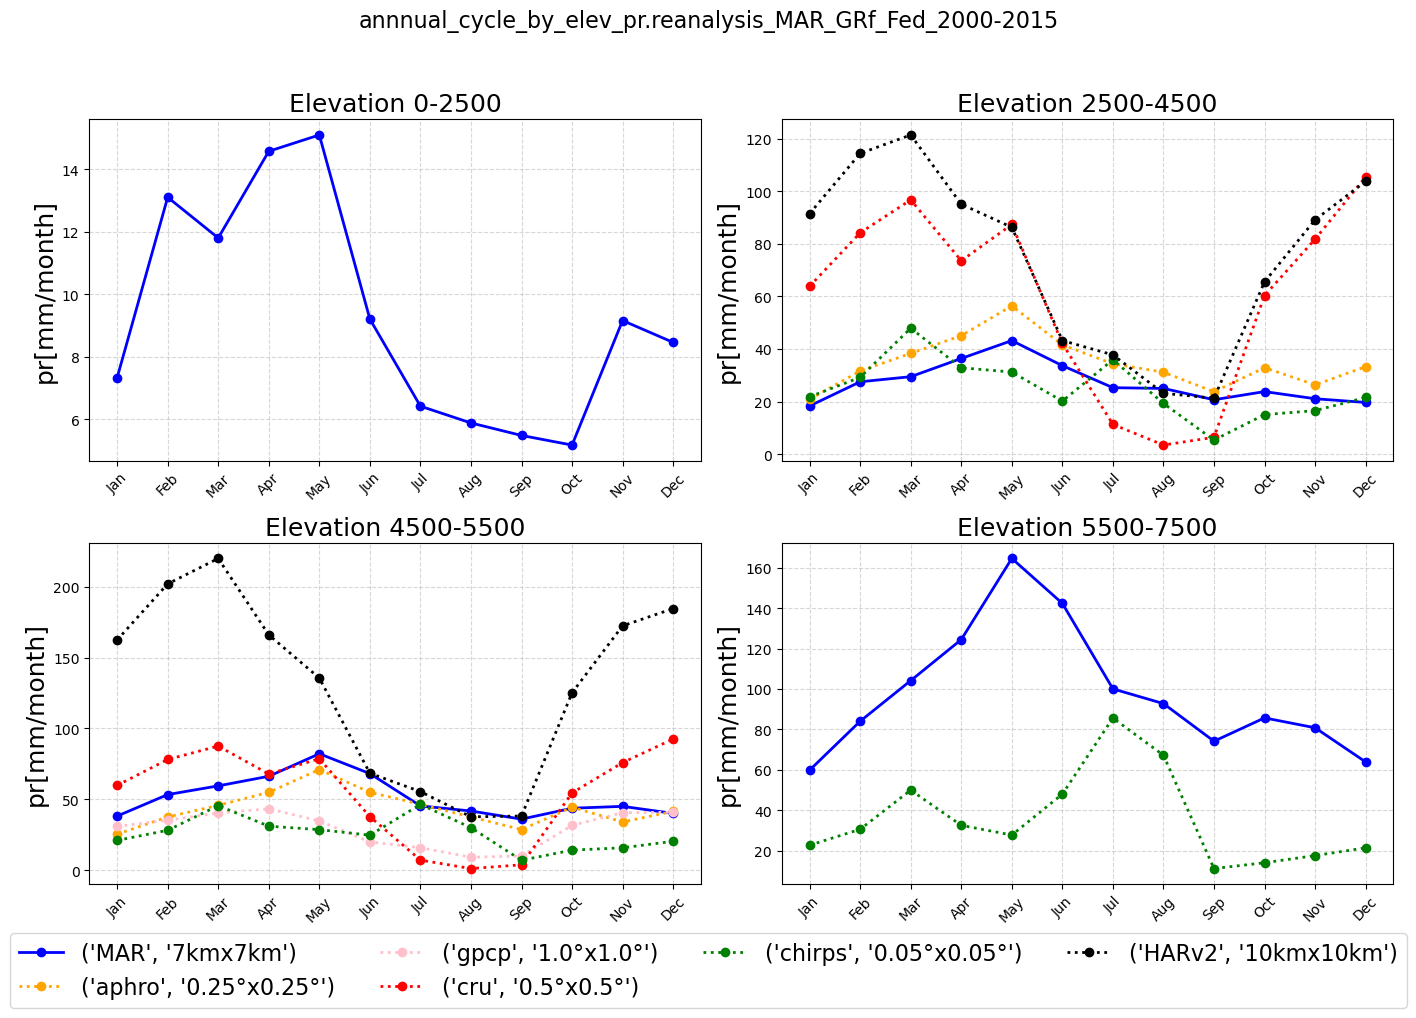

In [31]:
plotname=f'annnual_cycle_by_elev_{var}.reanalysis_MAR_{domain}_{str(iyr)}-{str(fyr)}'

olors = colorList
elev_labels = ['0-2500', '2500-4500', '4500-5500', '5500-7500']

months = np.arange(1, 13)

fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=False)
axs = axs.flatten()

for i in range(4):  # 4 elevation bands
    ax = axs[i]

    # Plot one line per dataset
    # ax.plot(months, ac_mean_vals_field1[i].values, 'o', linestyle='-',label=nameList[0], color=colors[0], linewidth=2)
    ax.plot(months, ac_mean_vals_field_gp[i].values, 'o', linestyle='-',label=nameList[0], color=colors[0], linewidth=2)

    ax.plot(months, ac_mean_vals_field3[i].values,'o', linestyle=':',label=nameList[0+1], color=colors[0+1], linewidth=2)
    ax.plot(months, ac_mean_vals_field4[i].values, 'o',linestyle=':',label=nameList[1+1], color=colors[1+1], linewidth=2)
    ax.plot(months, ac_mean_vals_field5[i].values, 'o',linestyle=':',label=nameList[2+1], color=colors[2+1], linewidth=2)
    ax.plot(months, ac_mean_vals_field6[i].values, 'o',linestyle=':',label=nameList[3+1], color=colors[3+1], linewidth=2)    
    ax.plot(months, ac_mean_vals_field7[i].values, 'o',linestyle=':',label=nameList[4+1], color=colors[4+1], linewidth=2)

    ax.set_title(f'Elevation {elev_labels[i]}', fontsize=18)
    ax.set_xticks(months)
    ax.set_ylabel(f'{var}[{units}]', fontsize=18)
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
    ax.grid(True, linestyle='--', alpha=0.5)

# Axis labels and legend
fig.suptitle(plotname, fontsize=16)
#fig.supxlabel('Month', fontsize=14)
#fig.supylabel('Snow Height [m]', fontsize=14)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.03),
    ncol=4,
    fontsize=16,
    frameon=True
)

# Adjust layout and save with full legend
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
#plt.savefig(plotsDir + 'monthly_snowheight_by_elevation.png', , dpi=300)

# Save figure (including legend outside)
plt.savefig(plotsDir+plotname+'.png', bbox_inches='tight')


plt.show()